# GAN test

In [24]:
import sys
sys.path.append("..")
import numpy as np
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels = 1),
    transforms.ToTensor()
])

dataset = datasets.MNIST(root = "./data", download = True, transform = transform)

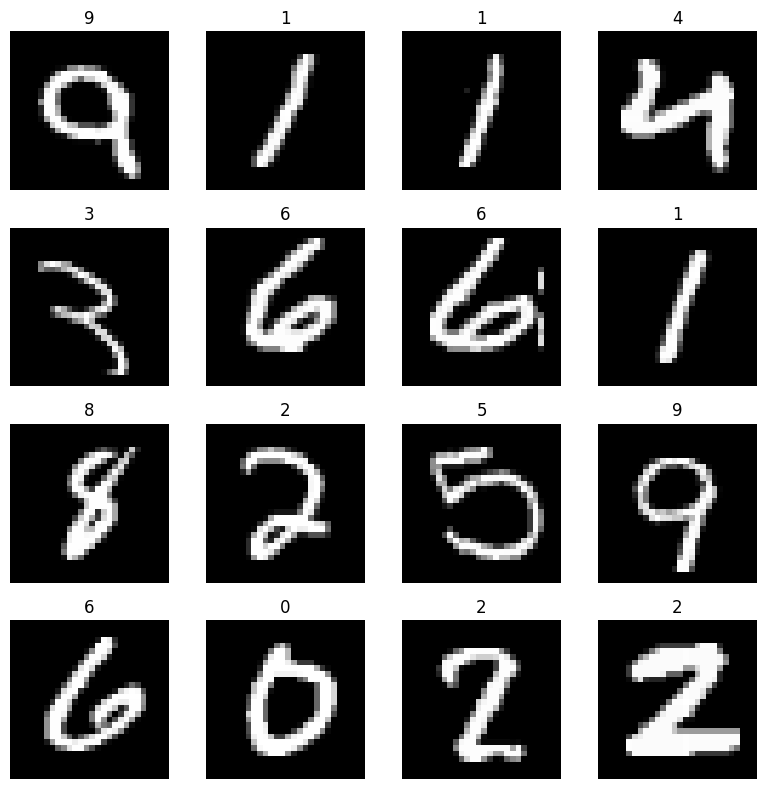

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image, label = dataset[np.random.randint(0, len(dataset))]
    image = image[0]
    ax.imshow(image, cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [26]:
image_dim = image.shape[0] * image.shape[1]
image_dim

784

In [155]:
from fnn import FNN
import torch
from torch import nn
from utils import device

latent_dim = 128

class Generator(nn.Module):
    def __init__(self, latent_dim: int) -> None:
        super().__init__()
        self._proj = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.LayerNorm(128 * 7 * 7),
            nn.LeakyReLU(),
        )
        self._net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size = 4, stride = 2, padding = 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(64, 64, kernel_size = 4, stride = 2, padding = 1),  
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
            nn.Conv2d(64, 1, kernel_size = 5, stride = 1, padding = 2),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        h = self._proj(z)
        h = h.view(z.shape[0], 128, 7, 7)
        return (self._net(h) + 1) / 2

class Discriminator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self._net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size = 4, stride = 2, padding = 1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size = 4, stride = 2, padding = 1),
            nn.LeakyReLU(),
            nn.Conv2d(64, 64, kernel_size = 5, stride = 1, padding = 2),
            nn.LeakyReLU(),
        )
        self._fc = nn.Sequential(
            nn.Linear(64 * 49, 2048),
            nn.LayerNorm(2048),
            nn.LeakyReLU(),
            nn.LayerNorm(2048),
            nn.Linear(2048, 1024),
            nn.LeakyReLU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self._net(x)
        x = x.flatten(start_dim = 1)
        return self._fc(x)

gen = Generator(latent_dim = latent_dim).to(device)
gen_optimizer = torch.optim.Adam(gen.parameters(), lr = 2e-4, betas = (0.5, 0.999))
disc = Discriminator().to(device)
disc_optimizer = torch.optim.Adam(disc.parameters(), lr = 2e-4, betas = (0.5, 0.999))

In [156]:
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm, trange

batch_size = 128
num_epochs = 200

dataloader = DataLoader(dataset, batch_size = batch_size, shuffle = True, drop_last = True)
bce_loss_with_logits = nn.BCEWithLogitsLoss()
gen.train()
disc.train()
...

Ellipsis

In [157]:
i = 0
for epoch in trange(num_epochs):
    for batch_idx, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        
        disc_optimizer.zero_grad(set_to_none = True)
        with torch.no_grad():
            fake_images = gen(torch.randn(batch_size, latent_dim, device = device))
        images = torch.cat([real_images, fake_images])
        output = disc(images)
        target = torch.cat([torch.ones_like(output[: batch_size]), torch.zeros_like(output[batch_size :])])
        disc_loss = bce_loss_with_logits(output, target)
        disc_loss.backward()
        clip_grad_norm_(disc.parameters(), max_norm = 1.0)
        disc_optimizer.step()

        for _ in range(3):
            gen_optimizer.zero_grad(set_to_none = True)
            fake_images = gen(torch.randn(batch_size, latent_dim, device = device))
            output = disc(fake_images)
            gen_loss = bce_loss_with_logits(output, torch.ones_like(output))
            gen_loss.backward()
            clip_grad_norm_(gen.parameters(), max_norm = 1.0)
            gen_optimizer.step()

        i += 1
        if i % 100 == 0:
            print(f"{i}, g: {gen_loss.item():.4f}, d: {disc_loss.item():.4f}")

  0%|          | 0/200 [00:00<?, ?it/s]

100, g: 1.2049, d: 0.6454
200, g: 1.2143, d: 0.6096
300, g: 1.2072, d: 0.3691
400, g: 1.9670, d: 0.3542


  0%|          | 1/200 [00:43<2:23:46, 43.35s/it]

500, g: 1.8521, d: 0.3358
600, g: 2.1873, d: 0.3137
700, g: 2.3612, d: 0.4246
800, g: 2.1588, d: 0.3742


  0%|          | 1/200 [01:55<6:23:10, 115.53s/it]


KeyboardInterrupt: 

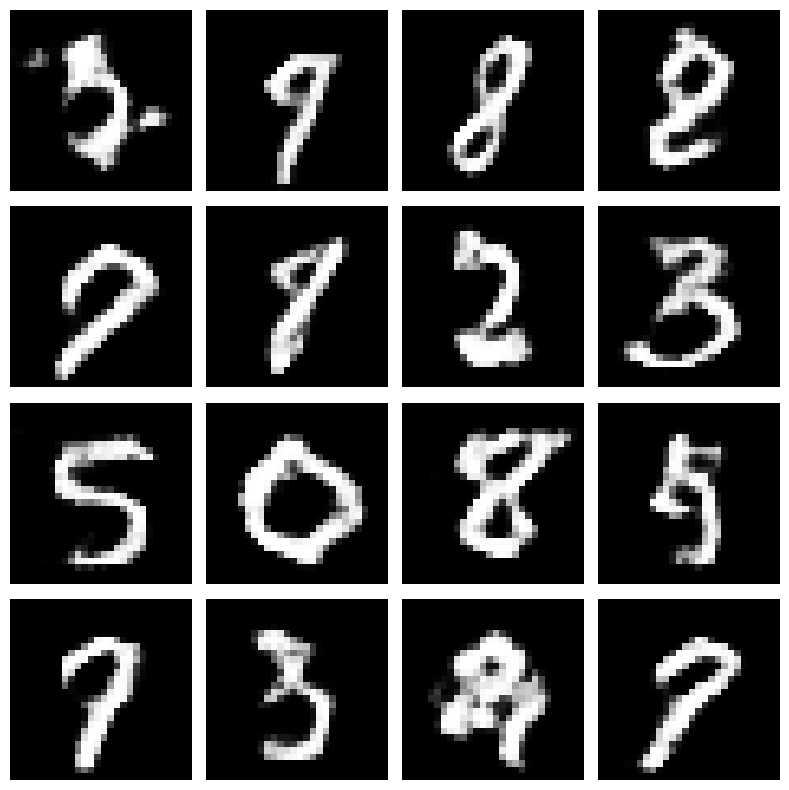

In [177]:
fig, axes = plt.subplots(4, 4, figsize = (8, 8))

gen.eval()
with torch.no_grad():
    fake_images = gen(torch.randn(16, latent_dim, device = device))

for i, ax in enumerate(axes.flatten()):
    image = fake_images[i, 0].cpu()
    ax.imshow(image, cmap = 'gray')
    ax.axis('off')

gen.train()
plt.tight_layout()
plt.show()